In [67]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

In [68]:
file = uproot.open("/lstr/sahara/dune/arahe/CP2Course/CP2GroupProject/TylerStuff/CCode/Analysis/gen1_mu_cc_1000_events_new.root")

In [69]:
tree = file["ana;1"]

In [70]:
branch = tree["gen1;1"]

In [71]:
Reco = branch.arrays(['eventID',
                      'recoNParticles',
                      'reco',
                      'recoGeneration',
                      'recoTrackLength',
                      'recoTrackScore',
                      'recodEdx',
                      'recoResidualRange'])
Sim = branch.arrays(['simNParticles',
                     'sim',
                     'simGeneration',
                     'simPdgCode',
                     'simEnergy',
                     'simID'])

In [72]:
rec = ak.zip({
    "eventID" : Reco['eventID'],
    "recoNParticles" : Reco['recoNParticles'],
    "recoGeneration" : Reco['recoGeneration'],
    "recoTrackLength" : Reco['recoTrackLength'],
    "recoTrackScore" : Reco['recoTrackScore'],
    "recodEdx" : Reco['recodEdx'],
    "recoResidualRange" : Reco['recoResidualRange']
})

In [73]:
sim = ak.zip({
    "simNParticles" : Sim['simNParticles'],
    "sim" : Sim["sim"],
    "simGeneration" : Sim['simGeneration'],
    "simPdgCode" : Sim["simPdgCode"],
    "simEnergy" : Sim['simEnergy'],
    "simID" : Sim["simID"]
})

In [74]:
#rec.recodEdx

In [75]:
def energyperlength(energy, length):
    result = energy / length
    return result

In [76]:
#energyperlength(rec.recodEdx,rec.recoTrackLength)

In [133]:
def cuts(reco):
    #Apply cuts
    e_and_l_cut = (reco.recodEdx<5) & (reco.recoTrackLength<10)
    cleaned_e_and_l = reco[e_and_l_cut]
    #Get dEdx per TrackLength
    e_per_l = energyperlength(cleaned_e_and_l.recodEdx, cleaned_e_and_l.recoTrackLength)
    return e_per_l

In [134]:
def selection_calc(reco):
    #Apply cut for 5 GeV and less than 1000 cm Track Length
    dEdx_cut = (reco.recodEdx>5) & (reco.recoTrackLength<1000)
    cleaned_dEdx = reco[dEdx_cut]
    #Invariant Mass Calculations
    #result = [float(calc_invm(p1,p2)) for p1,p2 in cleaned_charge]
    #flattened_dEdx = np.array([np.ravel(sub) for sub in cleaned_dEdx], dtype=object)
    #result = [float(energyperlength(energy,length)) for energy,length in cleaned_dEdx]
    return cleaned_dEdx#result

In [135]:
thething = cuts(rec)
thething

<Array [[[0.438, 0.448], []], ..., [[], ...]] type='935 * var * var * float32'>

In [136]:
flat_data = np.array([num for group in thething for sub in group for num in sub])
flat_data

array([0.43763238, 0.44757578, 0.541082  , ..., 0.09024286, 0.1155091 ,
       0.47626054], dtype=float32)

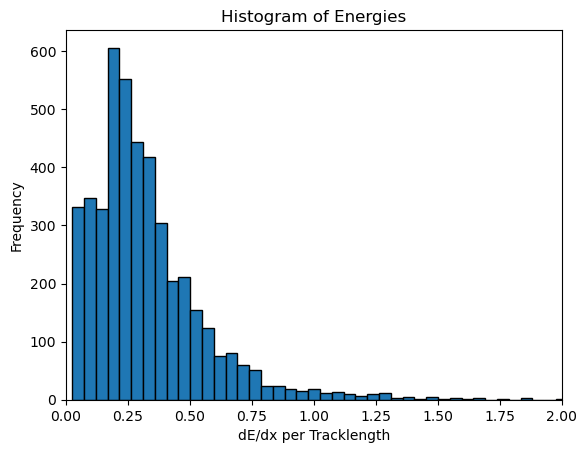

In [142]:
#rec_counts, rec_bins = np.histogram(flat_data, bins='auto')
#plt.hist(rec_bins[:-1], rec_bins, weights=rec_counts)
plt.hist(flat_data, bins=100, edgecolor = 'black')
plt.xlim(0, 2)
plt.xlabel('dE/dx per Tracklength')
plt.ylabel('Frequency')
plt.title('Histogram of Energies')
plt.show()